In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/miadul/heat-disease-predication-dataset/synthetic_heart_disease_dataset.csv


*This analysis examined which demographic, lifestyle, and clinical factors are associated with heart disease using a synthetic heart disease dataset from Kaggle containing 50,000 records. Overall, age, diabetes, previous heart attack, and total cholesterol showed the strongest independent associations with heart disease in the multivariable analysis.*

# Data Preparation

Identifying clinical factors associated with a patient's risk of developing a particular outcome.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/miadul/heat-disease-predication-dataset/synthetic_heart_disease_dataset.csv')

In [3]:
df.head(10)

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1
5,50,Male,116,186,25.3,Current,NaN,Sedentary,Average,Medium,...,0,1,0,0,171,91,106,97,225,0
6,67,Male,93,158,22.3,Never,Moderate,Moderate,Unhealthy,Low,...,0,0,0,0,153,82,85,145,156,1
7,51,Male,75,176,18.2,Former,NaN,Active,Average,Medium,...,0,0,1,0,117,63,89,143,154,0
8,54,Male,105,189,19.6,Current,NaN,Moderate,Healthy,High,...,0,1,0,0,164,97,75,147,267,0
9,74,Male,106,197,35.7,Current,Low,Moderate,Unhealthy,Low,...,0,0,0,0,114,69,87,117,195,0


In [4]:
df.shape

(50000, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Weight                 50000 non-null  int64  
 3   Height                 50000 non-null  int64  
 4   BMI                    50000 non-null  float64
 5   Smoking                50000 non-null  object 
 6   Alcohol_Intake         29891 non-null  object 
 7   Physical_Activity      50000 non-null  object 
 8   Diet                   50000 non-null  object 
 9   Stress_Level           50000 non-null  object 
 10  Hypertension           50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Hyperlipidemia         50000 non-null  int64  
 13  Family_History         50000 non-null  int64  
 14  Previous_Heart_Attack  50000 non-null  int64  
 15  Sy

In [6]:
df.isnull().sum()

Age                          0
Gender                       0
Weight                       0
Height                       0
BMI                          0
Smoking                      0
Alcohol_Intake           20109
Physical_Activity            0
Diet                         0
Stress_Level                 0
Hypertension                 0
Diabetes                     0
Hyperlipidemia               0
Family_History               0
Previous_Heart_Attack        0
Systolic_BP                  0
Diastolic_BP                 0
Heart_Rate                   0
Blood_Sugar_Fasting          0
Cholesterol_Total            0
Heart_Disease                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# Replacing all null values with 'No'
df.fillna('No', inplace=True)

In [9]:
df.describe()

,Age,Weight,Height,BMI,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.46406,84.547520,174.460000,28.984284,0.299620,0.199260,0.251660,0.400500,0.099280,139.299580,89.528800,84.449560,124.493020,224.556360,0.463460
std,14.43809,20.213257,14.420379,6.367494,0.458096,0.399448,0.433971,0.490005,0.299041,23.083544,17.258063,14.491325,31.691507,43.157467,0.498668
min,30.00000,50.000000,150.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,60.000000,60.000000,70.000000,150.000000,0.000000
25%,42.00000,67.000000,162.000000,23.500000,0.000000,0.000000,0.000000,0.000000,0.000000,119.000000,75.000000,72.000000,97.000000,187.000000,0.000000
50%,54.00000,85.000000,174.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.000000,90.000000,85.000000,125.000000,225.000000,0.000000
75%,67.00000,102.000000,187.000000,34.500000,1.000000,0.000000,1.000000,1.000000,0.000000,159.000000,104.000000,97.000000,152.000000,262.000000,1.000000
max,79.00000,119.000000,199.000000,40.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,119.000000,109.000000,179.000000,299.000000,1.000000


In [10]:
df.columns

Index(['Age', 'Gender', 'Weight', 'Height', 'BMI', 'Smoking', 'Alcohol_Intake',
       'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension', 'Diabetes',
       'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack',
       'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting',
       'Cholesterol_Total', 'Heart_Disease'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Weight                 50000 non-null  int64  
 3   Height                 50000 non-null  int64  
 4   BMI                    50000 non-null  float64
 5   Smoking                50000 non-null  object 
 6   Alcohol_Intake         50000 non-null  object 
 7   Physical_Activity      50000 non-null  object 
 8   Diet                   50000 non-null  object 
 9   Stress_Level           50000 non-null  object 
 10  Hypertension           50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Hyperlipidemia         50000 non-null  int64  
 13  Family_History         50000 non-null  int64  
 14  Previous_Heart_Attack  50000 non-null  int64  
 15  Sy

# Descriptive Statistics

The outcome variable is Heart_Disease

It is the dependent variable.

0 - No heart disease

1 - Heart disease

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

Is age associated with heart disease?

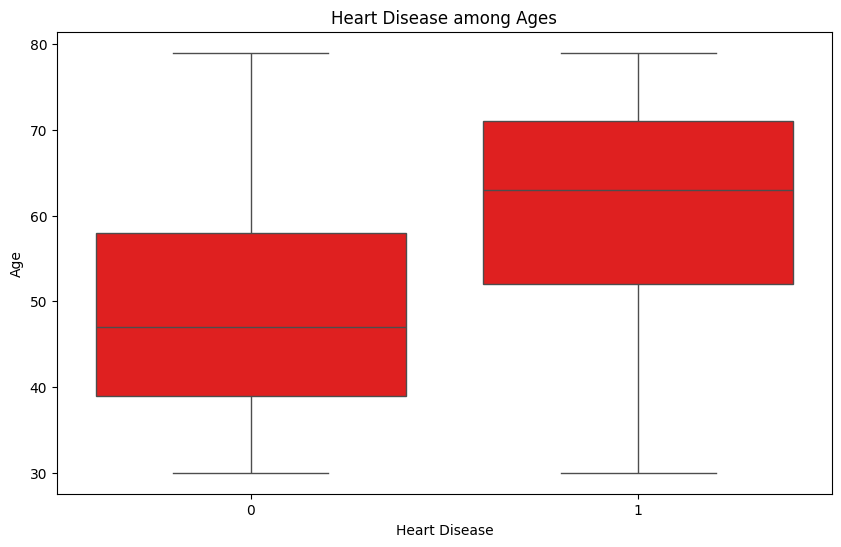

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Heart_Disease', y='Age', color='red')

plt.xlabel('Heart Disease')
plt.title("Heart Disease among Ages")
plt.show()

*Heart disease patients skew older, with a median around 63 vs. 47 for those without disease.*

Does your Cholesterol Total level determine if you have a heart disease?

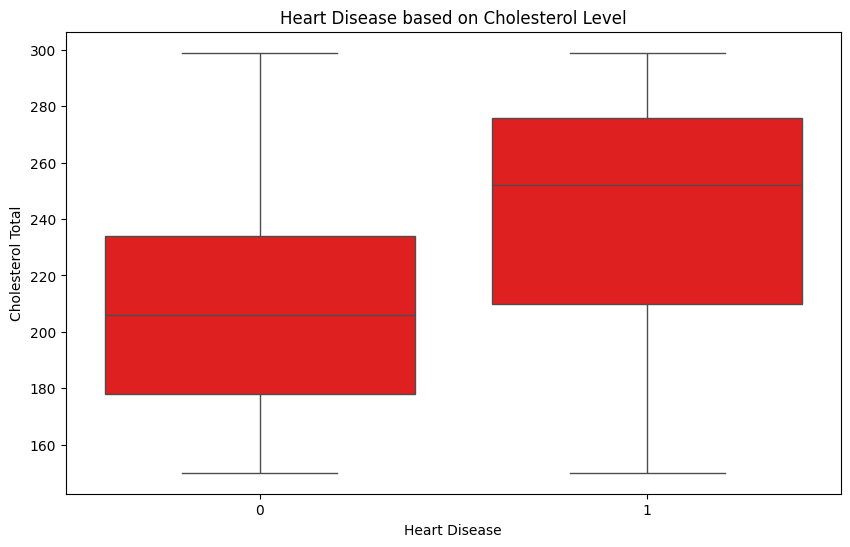

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Heart_Disease', y='Cholesterol_Total', color='red')

plt.ylabel('Cholesterol Total')
plt.xlabel('Heart Disease')
plt.title("Heart Disease based on Cholesterol Level")
plt.show()

*Median total cholesterol is visibly higher in the heart disease group (~252 vs. ~206 mg/dL).*

Are BMI and blood pressure different between patients with and without heart disease?

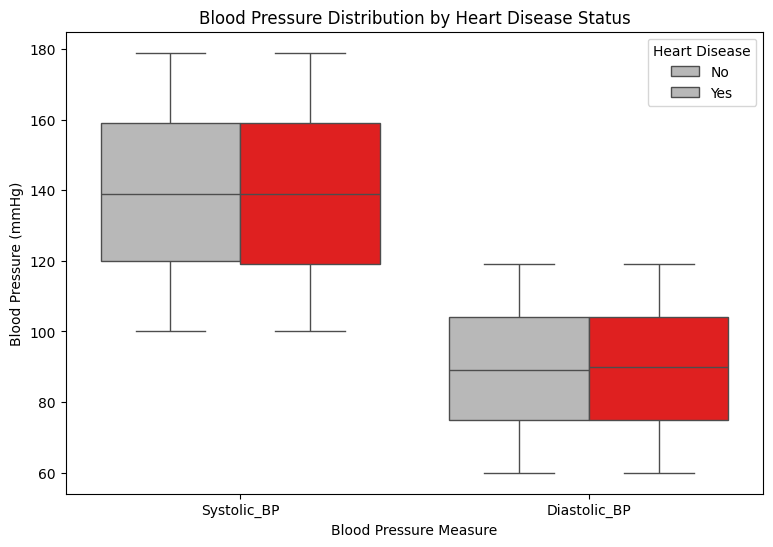

In [15]:
bp_long = df.melt(
    id_vars='Heart_Disease',
    value_vars=['Systolic_BP', 'Diastolic_BP'],
    var_name='Blood_Pressure_Type',
    value_name='Blood_Pressure'
)

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=bp_long,
    x='Blood_Pressure_Type',
    y='Blood_Pressure',
    hue='Heart_Disease',
    palette={
        0: '#B8B8B8',
        1: 'red'
    }
)

plt.xlabel('Blood Pressure Measure')
plt.ylabel('Blood Pressure (mmHg)')
plt.title('Blood Pressure Distribution by Heart Disease Status')
plt.legend(title='Heart Disease', labels=['No', 'Yes'])

plt.show()

*Systolic and diastolic BP distributions are nearly identical between groups, no visible separation.*

Are lifestyle factors such as smoking, alcohol intake, physical activity, diet, and stress associated with heart disease?

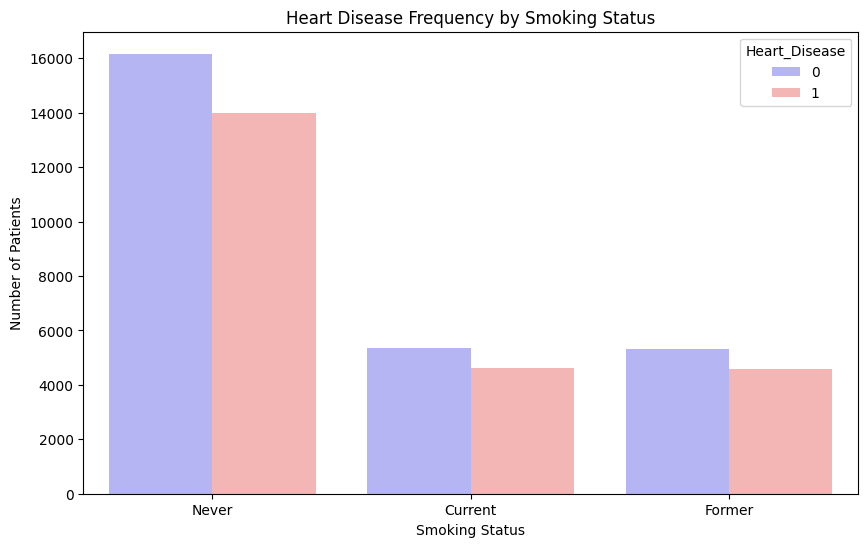

In [16]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Smoking', hue='Heart_Disease', palette='bwr')

plt.title('Heart Disease Frequency by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Number of Patients')
plt.show()

*Heart disease proportion looks flat across never/current/former smokers, no visible pattern.*

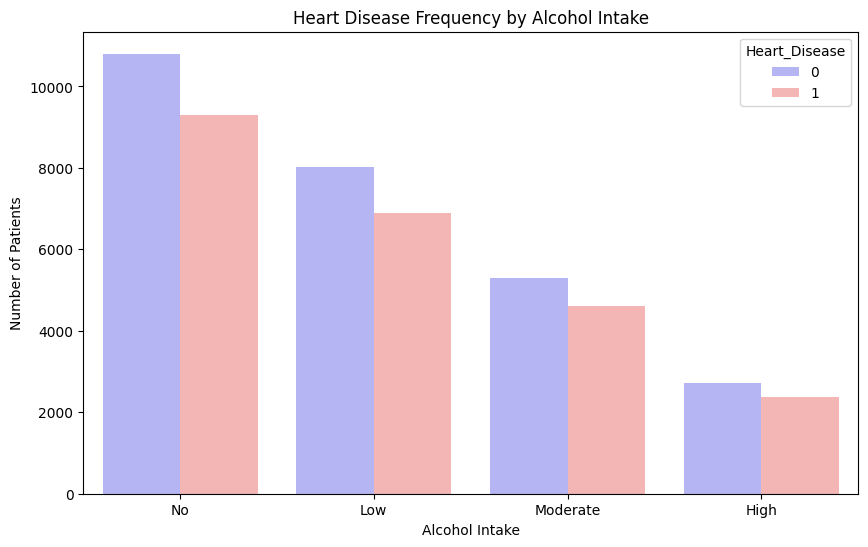

In [17]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Alcohol_Intake', hue='Heart_Disease', palette='bwr')

plt.title('Heart Disease Frequency by Alcohol Intake')
plt.xlabel('Alcohol Intake')
plt.ylabel('Number of Patients')
plt.show()

*Roughly the same disease proportion at every intake level, no clear gradient.*

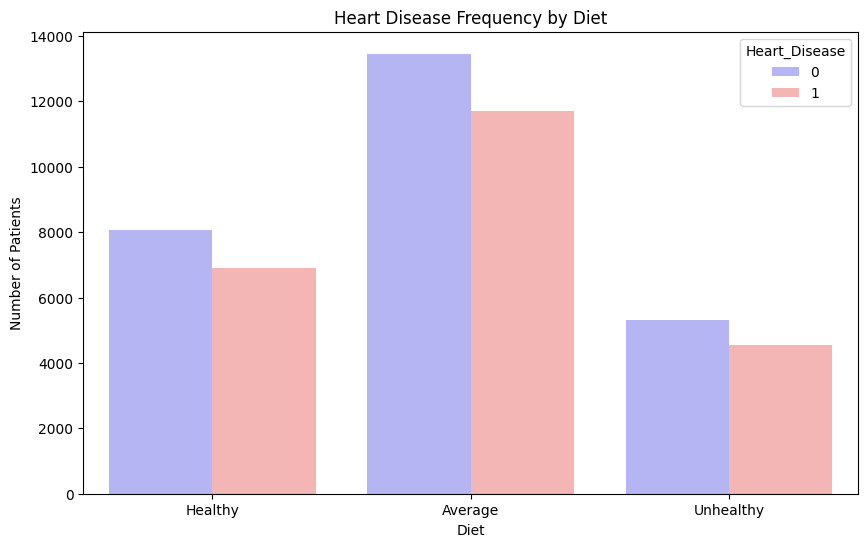

In [18]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Diet', hue='Heart_Disease', palette='bwr')

plt.title('Heart Disease Frequency by Diet')
plt.xlabel('Diet')
plt.ylabel('Number of Patients')
plt.show()

*Healthy, average, and unhealthy diets show almost identical disease proportions.*

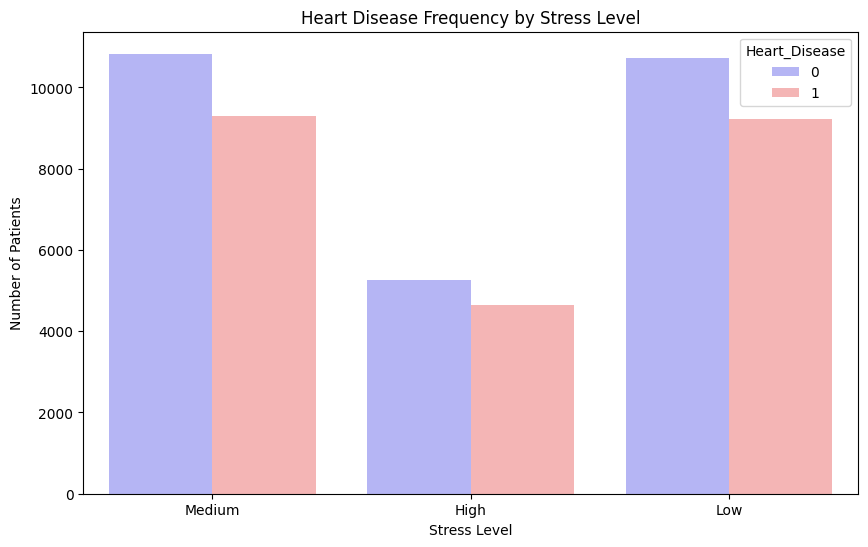

In [19]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Stress_Level', hue='Heart_Disease', palette='bwr')

plt.title('Heart Disease Frequency by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Number of Patients')
plt.show()

*Disease proportion stays roughly constant across low, medium, and high stress.*

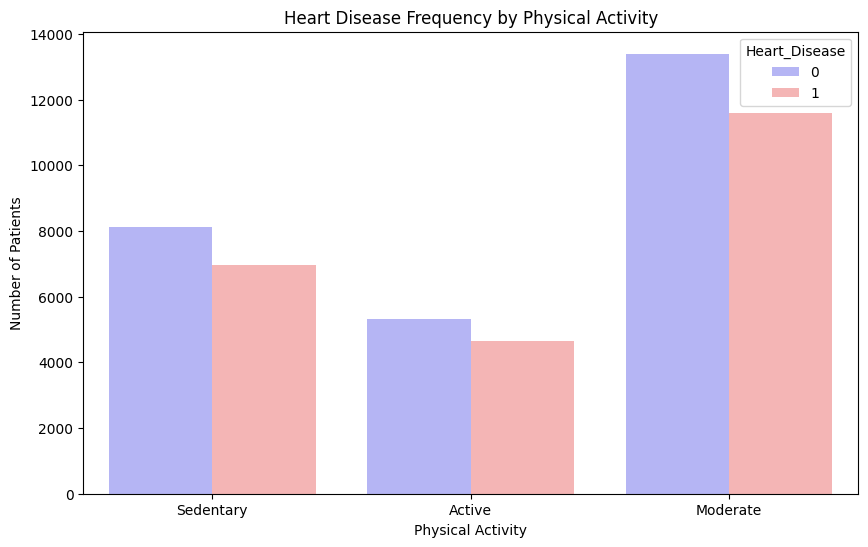

In [20]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Physical_Activity', hue='Heart_Disease', palette='bwr')

plt.title('Heart Disease Frequency by Physical Activity')
plt.xlabel('Physical Activity')
plt.ylabel('Number of Patients')
plt.show()

*Sedentary, moderate, and active groups all show a similar disease rate (~46%).*

Are existing conditions such as hypertension, diabetes, and hyperlipidemia associated with heart disease?

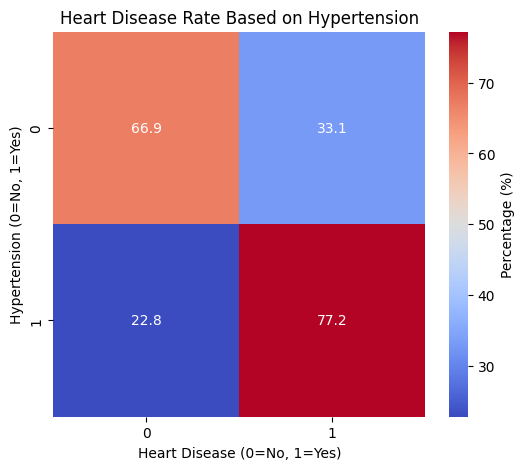

In [21]:
binary_matrix = pd.crosstab(df['Hypertension'], df['Heart_Disease'], normalize='index') * 100

plt.figure(figsize=(6, 5))

sns.heatmap(binary_matrix, annot=True, fmt='.1f', cmap='coolwarm', cbar_kws={'label': 'Percentage (%)'})

plt.title('Heart Disease Rate Based on Hypertension')
plt.ylabel('Hypertension (0=No, 1=Yes)')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.show()

*Heart disease rate jumps from 33.1% (no hypertension) to 77.2% (hypertension).*

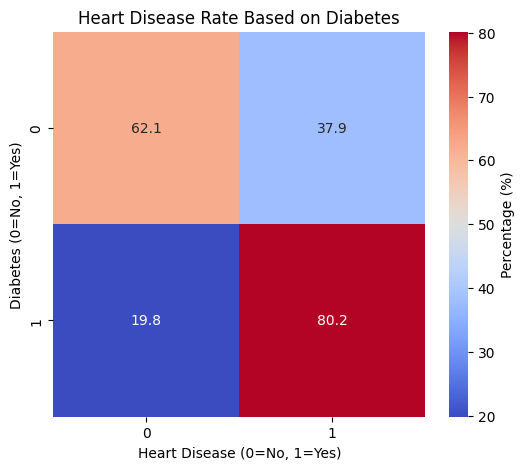

In [22]:
binary_matrix = pd.crosstab(df['Diabetes'], df['Heart_Disease'], normalize='index') * 100

plt.figure(figsize=(6, 5))

sns.heatmap(binary_matrix, annot=True, fmt='.1f', cmap='coolwarm', cbar_kws={'label': 'Percentage (%)'})

plt.title('Heart Disease Rate Based on Diabetes')
plt.ylabel('Diabetes (0=No, 1=Yes)')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.show()

*Heart disease rate jumps from 37.9% (no diabetes) to 80.2% (diabetes).*

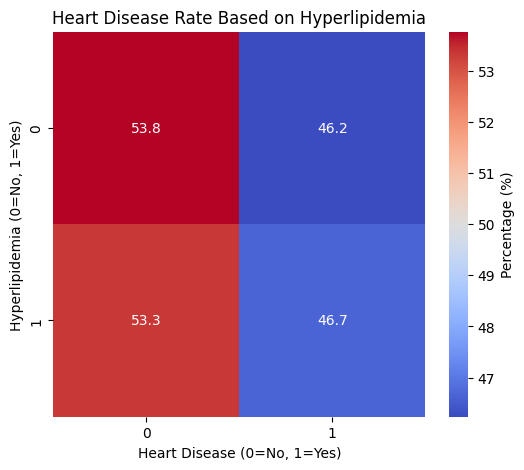

In [23]:
binary_matrix = pd.crosstab(df['Hyperlipidemia'], df['Heart_Disease'], normalize='index') * 100

plt.figure(figsize=(6, 5))

sns.heatmap(binary_matrix, annot=True, fmt='.1f', cmap='coolwarm', cbar_kws={'label': 'Percentage (%)'})

plt.title('Heart Disease Rate Based on Hyperlipidemia')
plt.ylabel('Hyperlipidemia (0=No, 1=Yes)')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.show()

*Almost no difference — 46.2% vs. 46.7% disease rate regardless of hyperlipidemia status.*

Are previous heart attack and family history associated with heart disease?

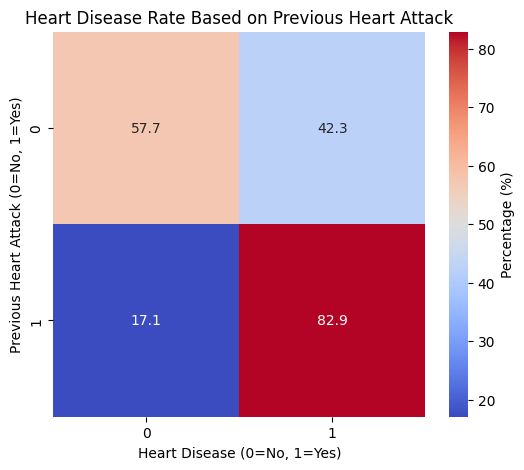

In [24]:
binary_matrix = pd.crosstab(df['Previous_Heart_Attack'], df['Heart_Disease'], normalize='index') * 100

plt.figure(figsize=(6, 5))

sns.heatmap(binary_matrix, annot=True, fmt='.1f', cmap='coolwarm', cbar_kws={'label': 'Percentage (%)'})

plt.title('Heart Disease Rate Based on Previous Heart Attack')
plt.ylabel('Previous Heart Attack (0=No, 1=Yes)')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.show()

*Heart disease rate rises sharply from 42.3% (no prior attack) to 82.9% (prior attack).*

Which factors remain independently associated with heart disease when considered together?

# Hypothesis Testing

In [25]:
from scipy.stats import ttest_ind
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from scipy.stats import chi2_contingency

Is age associated with heart disease?

In [26]:
df.groupby('Heart_Disease')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Heart_Disease,,,,,,,,
0,26827.0,49.363030,13.350928,30.0,39.0,47.0,58.0,79.0
1,23173.0,60.369439,13.358248,30.0,52.0,63.0,71.0,79.0


H₀: There is no difference in age between patients with and without heart disease.

H₁: There is a difference in age between patients with and without heart disease.

α = 0.05

If p < 0.05, we'll reject H₀.

If p ≥ 0.05, we'll fail to reject H₀.

In [27]:
no_disease = df.loc[df['Heart_Disease'] == 0, 'Age']
disease = df.loc[df['Heart_Disease'] == 1, 'Age']

stat, p = ttest_ind(no_disease, disease)

print("t-statistic:", stat)
print("p-value:", p)

t-statistic: -91.90010623135038
p-value: 0.0


Because p < 0.05, we reject H₀.

In [28]:
mean_difference = disease.mean() - no_disease.mean()

print("Mean difference:", mean_difference)

Mean difference: 11.006408787323295


In [29]:
#Confidence Level
group_0 = DescrStatsW(no_disease)
group_1 = DescrStatsW(disease)

result = CompareMeans(group_1, group_0)

ci = result.tconfint_diff(usevar='unequal')

print("95% CI:", ci)

95% CI: (np.float64(10.771658650368439), np.float64(11.241158924278151))


In [30]:
#Cohen's d
mean_diff = disease.mean() - no_disease.mean()

pooled_sd = np.sqrt(
    (
        (len(disease) - 1) * disease.var(ddof=1)
        + (len(no_disease) - 1) * no_disease.var(ddof=1)
    )
    /
    (len(disease) + len(no_disease) - 2)
)

cohens_d = mean_diff / pooled_sd

print("Cohen's d:", cohens_d)

Cohen's d: 0.8241833374504264


*Age differed significantly between patients with and without heart disease. Patients with heart disease were approximately 11 years older on average than those without heart disease (60.37 vs. 49.36 years; mean difference = 11.01, 95% CI 10.77–11.24; p < 0.001). The standardized effect size was large (Cohen's d = 0.82).*

Does total cholesterol differ between patients with and without heart disease?

In [31]:
df.groupby('Heart_Disease')['Cholesterol_Total'].describe()

,count,mean,std,min,25%,50%,75%,max
Heart_Disease,,,,,,,,
0,26827.0,209.551683,38.451375,150.0,178.0,206.0,234.0,299.0
1,23173.0,241.927027,41.771554,150.0,210.0,252.0,276.0,299.0


H₀: Mean total cholesterol is the same between the two heart-disease groups.

H₁: Mean total cholesterol differs between the two heart-disease groups.

α=0.05

In [32]:
no_disease = df.loc[df['Heart_Disease'] == 0, 'Cholesterol_Total']
disease = df.loc[df['Heart_Disease'] == 1, 'Cholesterol_Total']

stat, p = ttest_ind(no_disease, disease)

print("t-statistic:", stat)
print("p-value:", p)

t-statistic: -90.19485414459982
p-value: 0.0


Because p < 0.05, we reject H₀.

In [33]:
group_0 = DescrStatsW(no_disease)
group_1 = DescrStatsW(disease)

result = CompareMeans(group_1, group_0)

ci = result.tconfint_diff(usevar='unequal')

print("95% CI:", ci)

95% CI: (np.float64(31.66753775481166), np.float64(33.08315052065174))


In [34]:
mean_diff = disease.mean() - no_disease.mean()

pooled_sd = np.sqrt(
    (
        (len(disease) - 1) * disease.var(ddof=1)
        + (len(no_disease) - 1) * no_disease.var(ddof=1)
    )
    /
    (len(disease) + len(no_disease) - 2)
)

cohens_d = mean_diff / pooled_sd

print("Cohen's d:", cohens_d)

Cohen's d: 0.8088902065315845


*Total cholesterol was significantly higher among patients with heart disease compared with those without heart disease (241.93 vs. 209.55 mg/dL; mean difference = 32.38 mg/dL, 95% CI: 31.67–33.08; p < 0.001). The standardized effect size was large (Cohen's d = 0.81).*

Is smoking a lifestyle factor associated with heart disease?

In [35]:
pd.crosstab(
    df['Smoking'],
    df['Heart_Disease'],
    normalize='index'
) * 100

Heart_Disease,0,1
Smoking,,
Current,53.818364,46.181636
Former,53.670886,46.329114
Never,53.594164,46.405836


H₀: Smoking status and heart disease are independent.

H₁: Smoking status and heart disease are associated.

In [36]:
table = pd.crosstab(df['Smoking'], df['Heart_Disease'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 0.1528193486914405
p-value: 0.9264365915009418
Degrees of freedom: 2


Since p = 0.926 > 0.05, we fail to reject H₀.

In [37]:
n = table.to_numpy().sum()
min_dimension = min(table.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dimension))

print("Cramer's V:", cramers_v)

Cramer's V: 0.0017482525486407306


*Smoking status was not significantly associated with heart disease (χ²(2) = 0.153, p = 0.926). The proportion of patients with heart disease was similar among current smokers (46.18%), former smokers (46.33%), and never smokers (46.41%). Cramér's V = 0.002, indicating a negligible association.*

Is previous heart attack associated with heart disease?

In [38]:
pd.crosstab(
    df['Previous_Heart_Attack'],
    df['Heart_Disease']
)

Heart_Disease,0,1
Previous_Heart_Attack,,
0,25979,19057
1,848,4116


H₀: Previous heart attack and heart disease are independent.
H₁: Previous heart attack and heart disease are associated.
α = 0.05

In [39]:
pd.crosstab(
    df['Previous_Heart_Attack'],
    df['Heart_Disease'],
    normalize='index'
) * 100

Heart_Disease,0,1
Previous_Heart_Attack,,
0,57.684963,42.315037
1,17.082998,82.917002


In [40]:
table = pd.crosstab(
    df['Previous_Heart_Attack'],
    df['Heart_Disease']
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 2962.5253188989664
p-value: 0.0
Degrees of freedom: 1


χ² = 2962.53, df = 1, p < 0.001

Since p < 0.05, we reject the null hypothesis.

In [41]:
n = table.to_numpy().sum()
min_dimension = min(table.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dimension))

print("Cramer's V:", cramers_v)

Cramer's V: 0.24341426905171218


*Previous heart attack was significantly associated with heart disease in this dataset. Participants with a recorded previous heart attack had a substantially higher proportion of heart disease (82.92%) compared with those without a previous heart attack (42.32%). The association was statistically significant, χ²(1) = 2962.53, p < 0.001, with a moderate effect size (Cramér’s V = 0.24)*

Is an existing condition such as hypertension associated with heart disease?

In [42]:
pd.crosstab(
    df['Hypertension'],
    df['Heart_Disease']
)

Heart_Disease,0,1
Hypertension,,
0,23411,11608
1,3416,11565


H₀: Hypertension and heart disease are independent.

H₁: Hypertension and heart disease are associated.

α = 0.05

In [43]:
pd.crosstab(
    df['Hypertension'],
    df['Heart_Disease'],
    normalize='index'
) * 100

Heart_Disease,0,1
Hypertension,,
0,66.852280,33.147720
1,22.802216,77.197784


In [44]:
table = pd.crosstab(
    df['Hypertension'],
    df['Heart_Disease']
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 8185.765454239818
p-value: 0.0
Degrees of freedom: 1


χ² = 8185.77, df = 1, p < 0.001

Since p < 0.05, we reject H₀.

In [45]:
n = table.to_numpy().sum()
min_dimension = min(table.shape) - 1

cramers_v = np.sqrt(chi2 / (n * min_dimension))

print("Cramer's V:", cramers_v)

Cramer's V: 0.4046174848975219


*Hypertension was significantly associated with heart disease in this dataset. The proportion of participants with heart disease was substantially higher among those with hypertension than among those without hypertension (77.20% vs. 33.15%). The association was statistically significant, χ²(1) = 8185.77, p < 0.001, with a moderate-to-strong effect size (Cramér's V = 0.405).*

# Multivariable Analysis

In [46]:
import statsmodels.api as sm

In [47]:
categorical_cols = [
    'Gender',
    'Smoking',
    'Alcohol_Intake',
    'Physical_Activity',
    'Diet',
    'Stress_Level'
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Gender:
Gender
Female    25110
Male      24890
Name: count, dtype: int64

Smoking:
Smoking
Never      30160
Current     9965
Former      9875
Name: count, dtype: int64

Alcohol_Intake:
Alcohol_Intake
No          20109
Low         14913
Moderate     9895
High         5083
Name: count, dtype: int64

Physical_Activity:
Physical_Activity
Moderate     24976
Sedentary    15077
Active        9947
Name: count, dtype: int64

Diet:
Diet
Average      25169
Healthy      14975
Unhealthy     9856
Name: count, dtype: int64

Stress_Level:
Stress_Level
Medium    20133
Low       19941
High       9926
Name: count, dtype: int64


In [48]:
categorical_cols = [
    'Gender',
    'Smoking',
    'Alcohol_Intake',
    'Physical_Activity',
    'Diet',
    'Stress_Level'
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [49]:
df_model = df.copy()

df_model['Gender'] = pd.Categorical(
    df_model['Gender'],
    categories=['Female', 'Male']
)

df_model['Smoking'] = pd.Categorical(
    df_model['Smoking'],
    categories=['Never', 'Current', 'Former']
)

df_model['Alcohol_Intake'] = pd.Categorical(
    df_model['Alcohol_Intake'],
    categories=['No', 'Low', 'Moderate', 'High']
)

df_model['Physical_Activity'] = pd.Categorical(
    df_model['Physical_Activity'],
    categories=['Sedentary', 'Moderate', 'Active']
)

df_model['Diet'] = pd.Categorical(
    df_model['Diet'],
    categories=['Average', 'Healthy', 'Unhealthy']
)

df_model['Stress_Level'] = pd.Categorical(
    df_model['Stress_Level'],
    categories=['Low', 'Medium', 'High']
)

In [50]:
df_model = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=True
)

In [51]:
df_model.columns

Index(['Age', 'Weight', 'Height', 'BMI', 'Hypertension', 'Diabetes',
       'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack',
       'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting',
       'Cholesterol_Total', 'Heart_Disease', 'Gender_Male', 'Smoking_Current',
       'Smoking_Former', 'Alcohol_Intake_Low', 'Alcohol_Intake_Moderate',
       'Alcohol_Intake_High', 'Physical_Activity_Moderate',
       'Physical_Activity_Active', 'Diet_Healthy', 'Diet_Unhealthy',
       'Stress_Level_Medium', 'Stress_Level_High'],
      dtype='object')

In [52]:
X = df_model.drop([
    'Heart_Disease',
    'Weight',
    'Height',
    'Hypertension'
], axis=1)
y = df_model['Heart_Disease']

In [53]:
X.shape

(50000, 23)

In [54]:
X.columns

Index(['Age', 'BMI', 'Diabetes', 'Hyperlipidemia', 'Family_History',
       'Previous_Heart_Attack', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate',
       'Blood_Sugar_Fasting', 'Cholesterol_Total', 'Gender_Male',
       'Smoking_Current', 'Smoking_Former', 'Alcohol_Intake_Low',
       'Alcohol_Intake_Moderate', 'Alcohol_Intake_High',
       'Physical_Activity_Moderate', 'Physical_Activity_Active',
       'Diet_Healthy', 'Diet_Unhealthy', 'Stress_Level_Medium',
       'Stress_Level_High'],
      dtype='object')

In [55]:
X.isnull().sum().sum()

np.int64(0)

In [56]:
y.value_counts()

Heart_Disease
0    26827
1    23173
Name: count, dtype: int64

In [57]:
X = X.astype(float)

In [58]:
X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.385500
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          Heart_Disease   No. Observations:                50000
Model:                          Logit   Df Residuals:                    49976
Method:                           MLE   Df Model:                           23
Date:                Wed, 16 Sep 2026   Pseudo R-squ.:                  0.4417
Time:                        17:55:11   Log-Likelihood:                -19275.
converged:                       True   LL-Null:                       -34524.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        -13.9918      0.200    -69.976      0.000     -

In [59]:
odds_ratios = np.exp(result.params)

print(odds_ratios)

const                         8.383396e-07
Age                           1.106492e+00
BMI                           9.977113e-01
Diabetes                      2.721228e+01
Hyperlipidemia                1.020170e+00
Family_History                1.019654e+00
Previous_Heart_Attack         2.935932e+01
Systolic_BP                   9.995510e-01
Diastolic_BP                  1.000725e+00
Heart_Rate                    9.991214e-01
Blood_Sugar_Fasting           9.999306e-01
Cholesterol_Total             1.033697e+00
Gender_Male                   9.916500e-01
Smoking_Current               9.963031e-01
Smoking_Former                1.044952e+00
Alcohol_Intake_Low            9.891015e-01
Alcohol_Intake_Moderate       9.870615e-01
Alcohol_Intake_High           1.006527e+00
Physical_Activity_Moderate    1.030249e+00
Physical_Activity_Active      1.047089e+00
Diet_Healthy                  9.876250e-01
Diet_Unhealthy                9.803050e-01
Stress_Level_Medium           9.554744e-01
Stress_Leve

In [60]:
or_table = pd.DataFrame({
    'Odds_Ratio': np.exp(result.params),
    'CI_Lower': np.exp(result.conf_int()[0]),
    'CI_Upper': np.exp(result.conf_int()[1]),
    'P_Value': result.pvalues
})

or_table = or_table.round(3)

print(or_table)

                            Odds_Ratio  CI_Lower  CI_Upper  P_Value
const                            0.000     0.000     0.000    0.000
Age                              1.106     1.104     1.109    0.000
BMI                              0.998     0.994     1.002    0.253
Diabetes                        27.212    25.147    29.447    0.000
Hyperlipidemia                   1.020     0.963     1.081    0.497
Family_History                   1.020     0.969     1.073    0.454
Previous_Heart_Attack           29.359    26.440    32.602    0.000
Systolic_BP                      1.000     0.998     1.001    0.416
Diastolic_BP                     1.001     0.999     1.002    0.327
Heart_Rate                       0.999     0.997     1.001    0.318
Blood_Sugar_Fasting              1.000     0.999     1.001    0.863
Cholesterol_Total                1.034     1.033     1.034    0.000
Gender_Male                      0.992     0.943     1.042    0.742
Smoking_Current                  0.996     0.934

*Age remained significantly associated with heart disease after adjusting for other variables. Diabetes and previous heart attack also showed strong independent associations with heart disease. Total cholesterol remained significantly associated with heart disease, while the other included predictors were not statistically significant after adjustment.*

# Model Diagnostics

In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2

In [62]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data = vif_data.round(3)
print(vif_data)

                      Variable      VIF
0                        const  183.772
1                          Age    1.000
2                          BMI    1.001
3                     Diabetes    1.000
4               Hyperlipidemia    1.000
5               Family_History    1.001
6        Previous_Heart_Attack    1.001
7                  Systolic_BP    1.000
8                 Diastolic_BP    1.000
9                   Heart_Rate    1.000
10         Blood_Sugar_Fasting    1.000
11           Cholesterol_Total    1.000
12                 Gender_Male    1.001
13             Smoking_Current    1.066
14              Smoking_Former    1.066
15          Alcohol_Intake_Low    1.223
16     Alcohol_Intake_Moderate    1.197
17         Alcohol_Intake_High    1.126
18  Physical_Activity_Moderate    1.330
19    Physical_Activity_Active    1.330
20                Diet_Healthy    1.118
21              Diet_Unhealthy    1.118
22         Stress_Level_Medium    1.201
23           Stress_Level_High    1.201


The VIF analysis showed no concerning multicollinearity among the predictors, with all predictor VIFs below 1.33.

Likelihood Ratio Test

In [63]:
lr_stat = 2 * (result.llf - result.llnull)
df_lr = result.df_model
p_value = chi2.sf(lr_stat, df_lr)

print("Likelihood Ratio Statistic:", lr_stat)
print("Degrees of Freedom:", df_lr)
print("p-value:", p_value)

Likelihood Ratio Statistic: 30497.493460112702
Degrees of Freedom: 23.0
p-value: 0.0


The full logistic regression model provides a statistically significant improvement in fit compared with the intercept-only model.

# Predictive Performance

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    classification_report
)

ROC-AUC

In [65]:
y_prob = result.predict(X)

print(y_prob.head())

0    0.066455
1    0.024436
2    0.683229
3    0.954272
4    0.464301
dtype: float64


In [66]:
auc = roc_auc_score(y, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9020491021721028


Modelling

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (40000, 24)
Test set: (10000, 24)


In [68]:
train_model = sm.Logit(y_train, X_train)
train_result = train_model.fit()

print(train_result.summary())

Optimization terminated successfully.
         Current function value: 0.385733
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:          Heart_Disease   No. Observations:                40000
Model:                          Logit   Df Residuals:                    39976
Method:                           MLE   Df Model:                           23
Date:                Wed, 16 Sep 2026   Pseudo R-squ.:                  0.4413
Time:                        17:55:15   Log-Likelihood:                -15429.
converged:                       True   LL-Null:                       -27619.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        -14.0433      0.224    -62.691      0.000     -

In [69]:
y_test_prob = train_result.predict(X_test)

print(y_test_prob.head())

5250     0.996805
1533     0.313293
30177    0.932207
46041    0.970372
30695    0.977690
dtype: float64


In [70]:
test_auc = roc_auc_score(y_test, y_test_prob)

print("Test ROC-AUC:", test_auc)

Test ROC-AUC: 0.9030756501395939


In [71]:
y_test_pred = (y_test_prob >= 0.5).astype(int)

print(y_test_pred[:10])

5250     1
1533     0
30177    1
46041    1
30695    1
22112    1
2216     1
20832    1
27248    1
37161    1
dtype: int64


In [72]:
cm = confusion_matrix(y_test, y_test_pred)

print(cm)

[[4503  862]
 [ 973 3662]]


In [73]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8165
Precision: 0.8094606542882405
Recall: 0.7900755124056095
F1 Score: 0.799650616879572


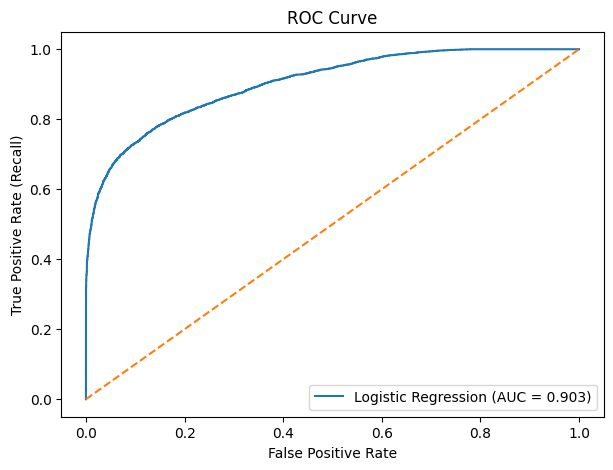

In [74]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

auc = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [75]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83      5365
           1       0.81      0.79      0.80      4635

    accuracy                           0.82     10000
   macro avg       0.82      0.81      0.82     10000
weighted avg       0.82      0.82      0.82     10000



The predictors therefore provide sufficiently independent information for the regression model.

In [76]:
# Extract coefficients
coef = train_result.params

# Convert coefficients to odds ratios
odds_ratios = np.exp(coef)

# Get 95% confidence intervals for the coefficients
conf = train_result.conf_int()

# Convert confidence intervals from log-odds to odds ratios
conf_odds = np.exp(conf)

# Create results table
results_table = pd.DataFrame({
    'Odds_Ratio': odds_ratios,
    'CI_Lower': conf_odds[0],
    'CI_Upper': conf_odds[1],
    'P_Value': train_result.pvalues
})

results_table

,Odds_Ratio,CI_Lower,CI_Upper,P_Value
const,7.962806e-07,5.133219e-07,0.000001,0.000000
Age,1.106684e+00,1.103978e+00,1.109396,0.000000
BMI,9.967185e-01,9.923514e-01,1.001105,0.142356
Diabetes,2.679041e+01,2.452778e+01,29.261760,0.000000
Hyperlipidemia,1.019592e+00,9.560873e-01,1.087315,0.554290
Family_History,1.032692e+00,9.754879e-01,1.093250,0.268554
Previous_Heart_Attack,2.875377e+01,2.558706e+01,32.312403,0.000000
Systolic_BP,9.998254e-01,9.986172e-01,1.001035,0.777180
Diastolic_BP,1.001068e+00,9.994448e-01,1.002693,0.197348
Heart_Rate,9.993381e-01,9.974101e-01,1.001270,0.501550


In [77]:
results_table = results_table.drop('const')

results_table = results_table.round({
    'Odds_Ratio': 3,
    'CI_Lower': 3,
    'CI_Upper': 3,
    'P_Value': 4
})

results_table

,Odds_Ratio,CI_Lower,CI_Upper,P_Value
Age,1.107,1.104,1.109,0.0000
BMI,0.997,0.992,1.001,0.1424
Diabetes,26.790,24.528,29.262,0.0000
Hyperlipidemia,1.020,0.956,1.087,0.5543
Family_History,1.033,0.975,1.093,0.2686
Previous_Heart_Attack,28.754,25.587,32.312,0.0000
Systolic_BP,1.000,0.999,1.001,0.7772
Diastolic_BP,1.001,0.999,1.003,0.1973
Heart_Rate,0.999,0.997,1.001,0.5016
Blood_Sugar_Fasting,1.000,0.999,1.001,0.9605


# Interpretation and Limitations

*The multivariable analysis suggests that age, diabetes, previous heart attack, and total cholesterol were independently associated with heart disease in this dataset. The model showed good discrimination on the test set, with an AUC of 0.903, indicating strong ability to distinguish between participants with and without heart disease.*

*However, the results should be interpreted with caution. The dataset is synthetic, so the findings may not reflect real-world clinical relationships. The analysis identifies associations, not causation, and the recorded previous heart attack variable may overlap with the definition of heart disease, potentially inflating its association. In addition, missing alcohol-intake values were treated as “No,” which may introduce bias. Finally, the model was evaluated on this dataset only, so its performance should not be assumed to generalize to real patient populations.*

# Next Steps

*With real clinical data, I would validate these findings in an independent patient population, investigate the relationship between previous heart attack and the outcome definition, and consider excluding or redefining that variable if it creates outcome overlap. I would also examine missing-data patterns more carefully and assess model calibration before considering clinical use.*